# SHAP-объяснения для CreditNet

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap

sys.path.append(str(Path('..').resolve()))
from src.explainer import CreditExplainer
from src.model import CreditTrainer
from src.text_generator import generate_explanation

## 1. Загрузка модели и данных

In [2]:
processed = Path('..') / 'data' / 'processed'
X_train = np.load(processed / 'X_train.npy')
X_test = np.load(processed / 'X_test.npy')
y_test = np.load(processed / 'y_test.npy')
feature_names = json.loads((processed / 'feature_names.json').read_text(encoding='utf-8'))

trainer = CreditTrainer.load(processed / 'model.pt', device='cpu')
explainer = CreditExplainer(trainer.model, X_train, feature_names)

print('Артефакты загружены успешно')

Артефакты загружены успешно


## 2. Глобальный анализ

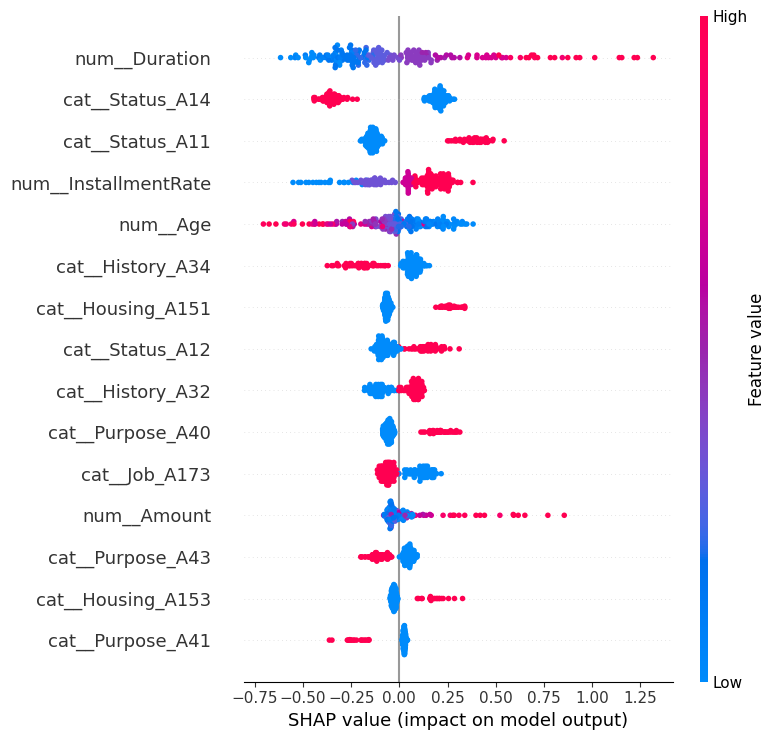

In [3]:
X_batch = X_test[:200]
sv = []
for i in range(len(X_batch)):
    one = explainer.explain(X_batch[i:i+1])
    sv.append(one['shap_values'])
sv = np.array(sv)

shap.summary_plot(sv, X_batch, feature_names=feature_names, max_display=15)

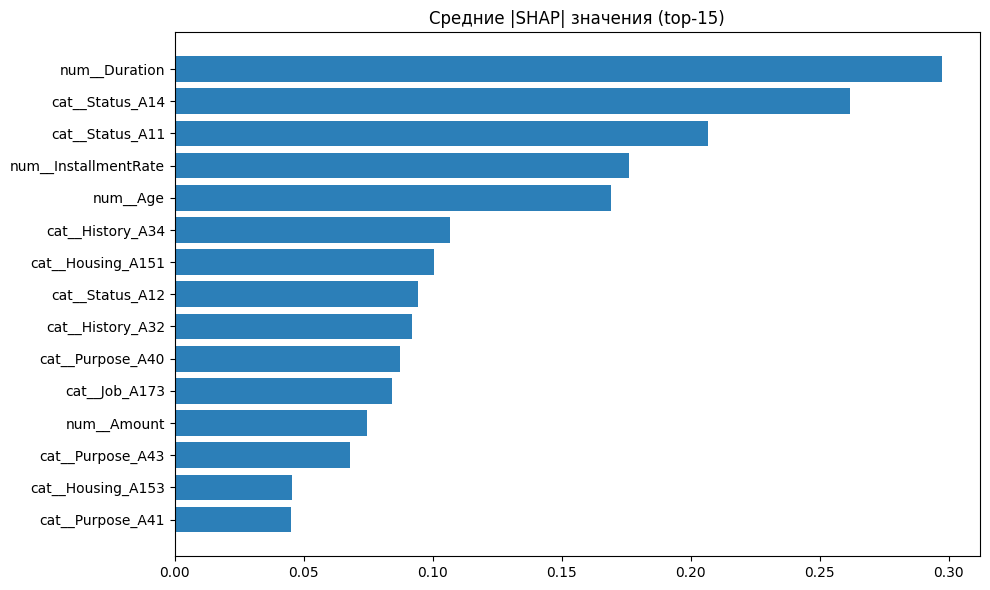

In [4]:
mean_abs = np.mean(np.abs(sv), axis=0)
top_idx = np.argsort(mean_abs)[-15:]
plt.figure(figsize=(10, 6))
plt.barh([feature_names[i] for i in top_idx], mean_abs[top_idx], color='#2c7fb8')
plt.title('Средние |SHAP| значения (top-15)')
plt.tight_layout()
plt.show()

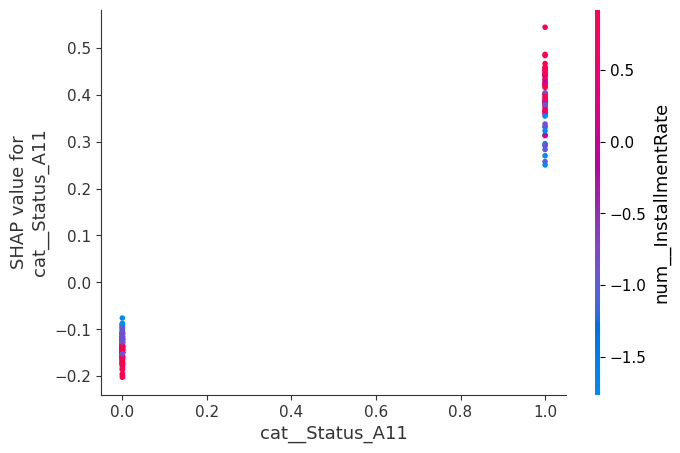

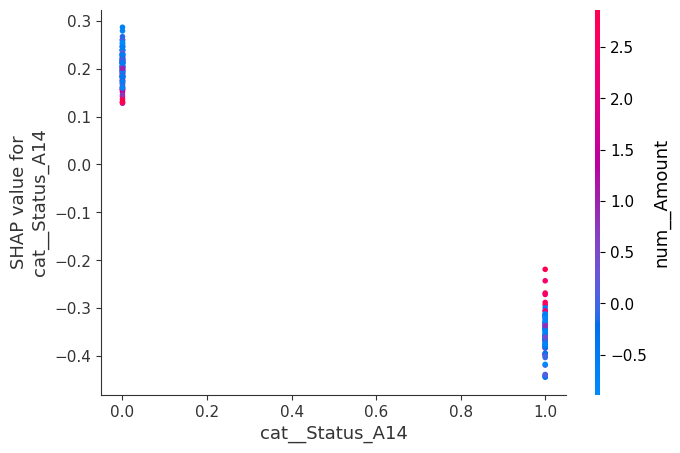

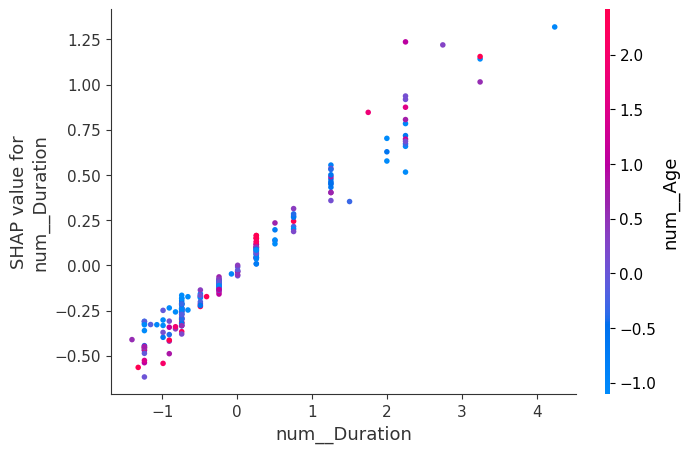

In [5]:
top3 = np.argsort(mean_abs)[-3:]
for i in top3:
    shap.dependence_plot(i, sv, X_batch, feature_names=feature_names)

Вывод: глобальные графики выделяют ключевые факторы риска и защищенности на всей выборке.

## 3. Локальные объяснения (3 примера)


Высокий риск (index=23, prob=0.822)
Решение: ОТКАЗ. Вероятность дефолта: 82.2%. Основные причины риска: Статус счета (+0.416), Тип жилья (+0.256), Нагрузка по платежу (+0.240). Факторы, снижающие риск: Тип жилья (-0.082), Цель кредита (-0.042).


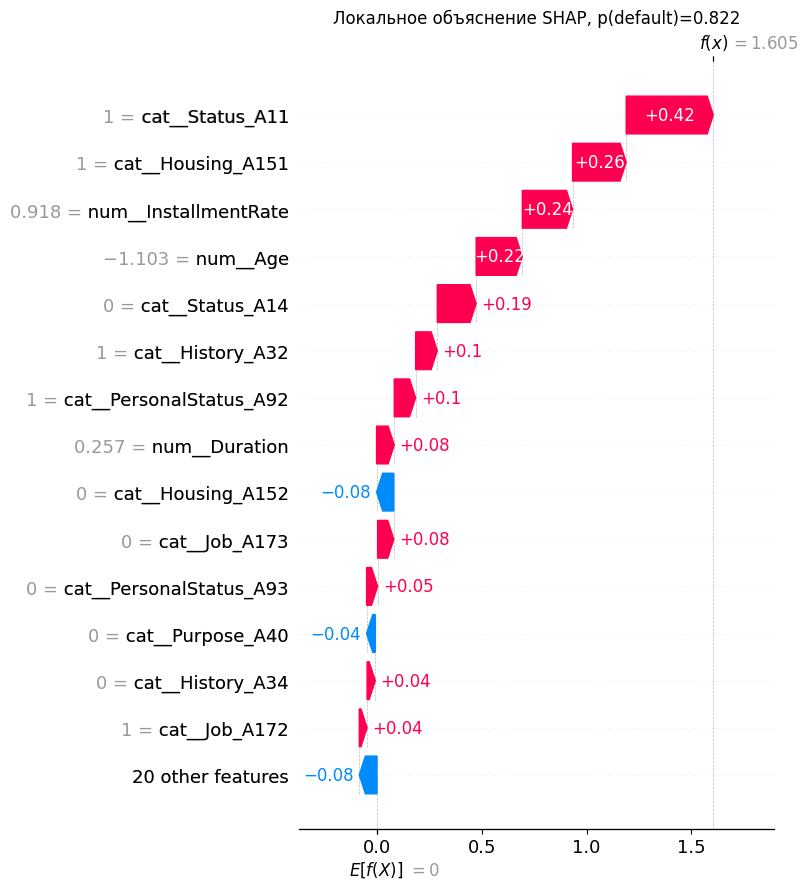


Низкий риск (index=12, prob=0.120)
Решение: ОДОБРЕНИЕ. Вероятность дефолта: 12.0%. Основные причины риска: Тип занятости (+0.114), Цель кредита (+0.027), Тип занятости (+0.016). Факторы, снижающие риск: Срок кредита (-0.410), Статус счета (-0.331).


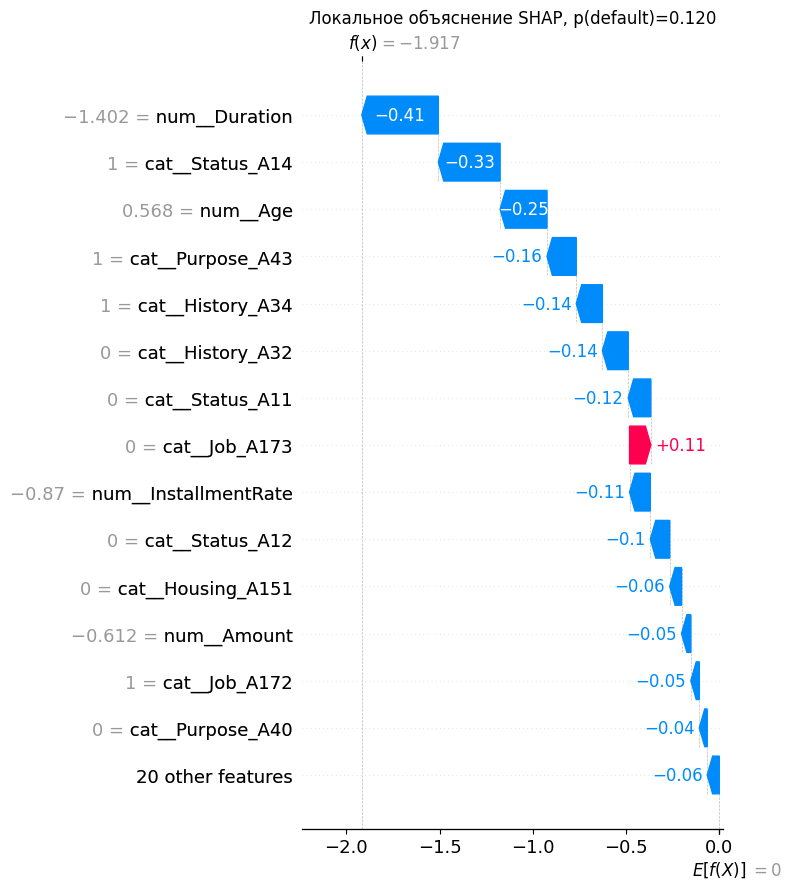


Пограничный случай (index=0, prob=0.482)
Решение: ОДОБРЕНИЕ. Вероятность дефолта: 48.2%. Основные причины риска: Статус счета (+0.213), Статус счета (+0.145), Кредитная история (+0.063). Факторы, снижающие риск: Статус счета (-0.132), Срок кредита (-0.093).


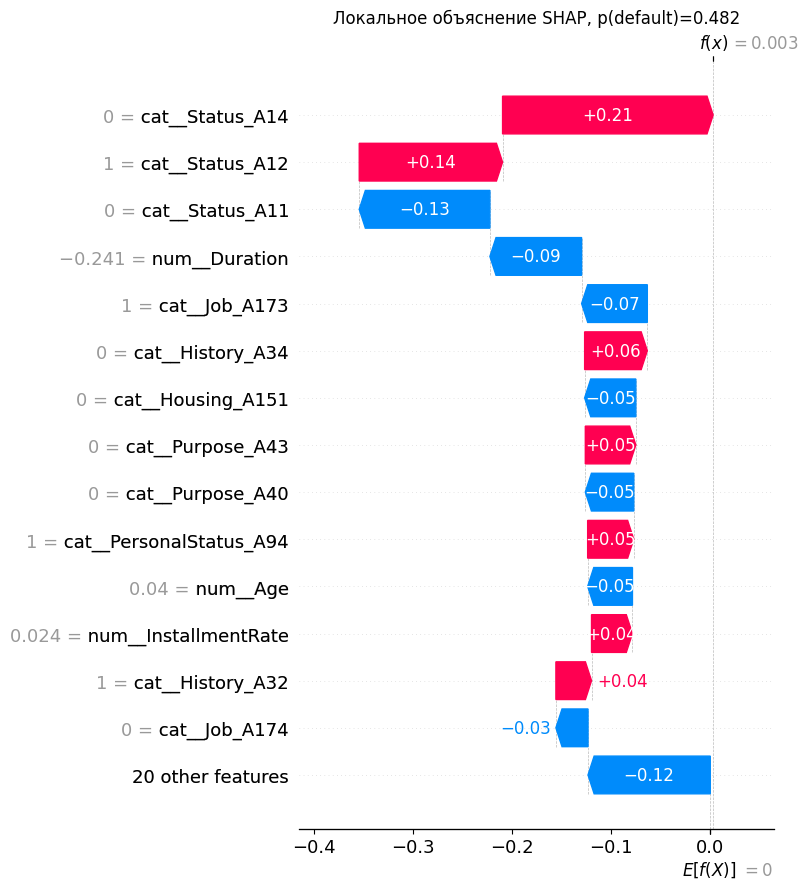

In [6]:
probs = trainer.predict_proba(X_test)
idx_high = int(np.where(probs > 0.7)[0][0]) if np.any(probs > 0.7) else int(np.argmax(probs))
idx_low = int(np.where(probs < 0.3)[0][0]) if np.any(probs < 0.3) else int(np.argmin(probs))
mid_candidates = np.where((probs >= 0.4) & (probs <= 0.6))[0]
idx_mid = int(mid_candidates[0]) if len(mid_candidates) > 0 else int(np.argsort(np.abs(probs - 0.5))[0])

cases = [('Высокий риск', idx_high), ('Низкий риск', idx_low), ('Пограничный случай', idx_mid)]
for title, idx in cases:
    info = explainer.explain(X_test[idx:idx+1])
    print('\n' + '=' * 80)
    print(title, f"(index={idx}, prob={info['prediction']:.3f})")
    print(generate_explanation(info))

    plt.figure(figsize=(9, 6))
    explainer.plot_waterfall(info['shap_values'], info['feature_names'], info['prediction'], info['sample'])
    plt.show()

Вывод: локальные объяснения показывают, почему именно для конкретного клиента модель дает высокий или низкий риск.

## 4. What-if анализ для клиента с отказом

In [7]:
base_idx = idx_high
x0 = X_test[base_idx].copy()
p0 = trainer.predict_proba(x0.reshape(1, -1))[0]

# Попытка изменения числовых признаков через поиск имен в feature_names
amount_i = [i for i, f in enumerate(feature_names) if f.endswith('Amount')]
duration_i = [i for i, f in enumerate(feature_names) if f.endswith('Duration')]
history_i = [i for i, f in enumerate(feature_names) if 'History' in f]

x1 = x0.copy()
if amount_i:
    x1[amount_i[0]] = x1[amount_i[0]] * 0.7
if duration_i:
    x1[duration_i[0]] = x1[duration_i[0]] * (24.0 / 36.0)
if len(history_i) >= 2:
    i_best = history_i[0]
    i_worst = history_i[-1]
    x1[i_best], x1[i_worst] = x1[i_worst], x1[i_best]

p1 = trainer.predict_proba(x1.reshape(1, -1))[0]

print(f'Исходная вероятность: {p0:.3f}')
print(f'После what-if: {p1:.3f}')
print(f'Изменение: {p1 - p0:+.3f}')

Исходная вероятность: 0.822
После what-if: 0.818
Изменение: -0.005


Итог: what-if анализ помогает объяснить клиенту и менеджеру, какие изменения в профиле заявки могут снизить риск дефолта.